# Logistic Regression

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Train shape: (4455, 17)
Test shape:  (1114, 17)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    198
Name: count, dtype: int64
Balanced train shape: (697, 17)
Class weights: {np.int64(0): np.float64(0.7770345596432553), np.int64(1): np.float64(1.1616666666666666), np.int64(2): np.float64(1.1734006734006734)}

Outputs ready for modeling:
  X_train_bal       → (697, 17) (balanced, scaled)
  y_train_bal       → 697 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
}

grid_lr = run_grid_search(
    LogisticRegression(
        solver="saga", class_weight=class_weight_dict,
        max_iter=2000, random_state=42,
    ),
    param_grid,
    X_train_bal,
    y_train_bal,
)
lr = grid_lr.best_estimator_

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)

print("Logistic Regression training complete.")
print(f"Best C:           {grid_lr.best_params_['C']}")
print(f"Best penalty:     {grid_lr.best_params_['penalty']}")
print(f"Best CV F1 Macro: {grid_lr.best_score_:.4f}")

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-p

Logistic Regression training complete.
Best C:           100
Best penalty:     l1
Best CV F1 Macro: 0.9474


/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Modeling
### DIAGNOSTIC PLOT 1: Feature Coefficients (OvR)

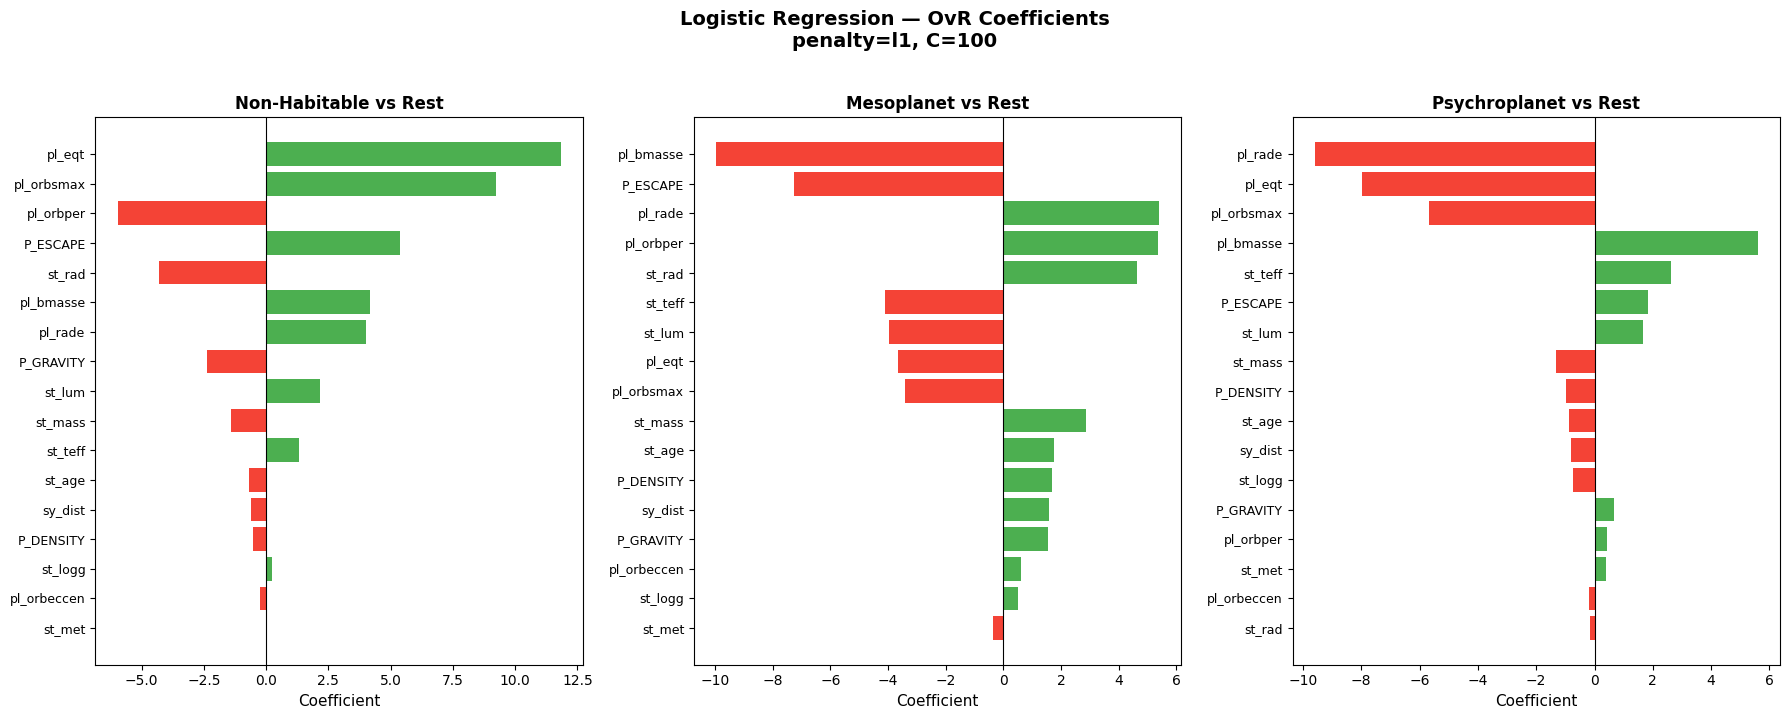

↑ Green = positive weight (pushes toward this class), red = negative (pushes away).
  L1 penalty produces sparse coefficients — some will be exactly 0.
  Compare across panels to see which features are shared vs class-specific signals.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
boundary_labels = ["Non-Habitable vs Rest", "Mesoplanet vs Rest", "Psychroplanet vs Rest"]

for cls_idx, ax in enumerate(axes):
    weights = lr.coef_[cls_idx]
    sorted_idx = np.argsort(np.abs(weights))[::-1]
    sorted_weights = weights[sorted_idx]
    sorted_names = [FEATURES[i] for i in sorted_idx]
    bar_colors = ["#4CAF50" if w > 0 else "#F44336" for w in sorted_weights]

    ax.barh(range(len(sorted_names)), sorted_weights, color=bar_colors, edgecolor="none")
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Coefficient", fontsize=11)
    ax.set_title(boundary_labels[cls_idx], fontsize=12, fontweight="bold")

fig.suptitle(
    f"Logistic Regression — OvR Coefficients\n"
    f"penalty={lr.penalty}, C={lr.C}",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
save_plot("lr_feature_coefficients")
plt.show()

print("↑ Green = positive weight (pushes toward this class), red = negative (pushes away).")
print("  L1 penalty produces sparse coefficients — some will be exactly 0.")
print("  Compare across panels to see which features are shared vs class-specific signals.")

### DIAGNOSTIC PLOT 2: Regularisation Path (C vs CV F1 Macro)

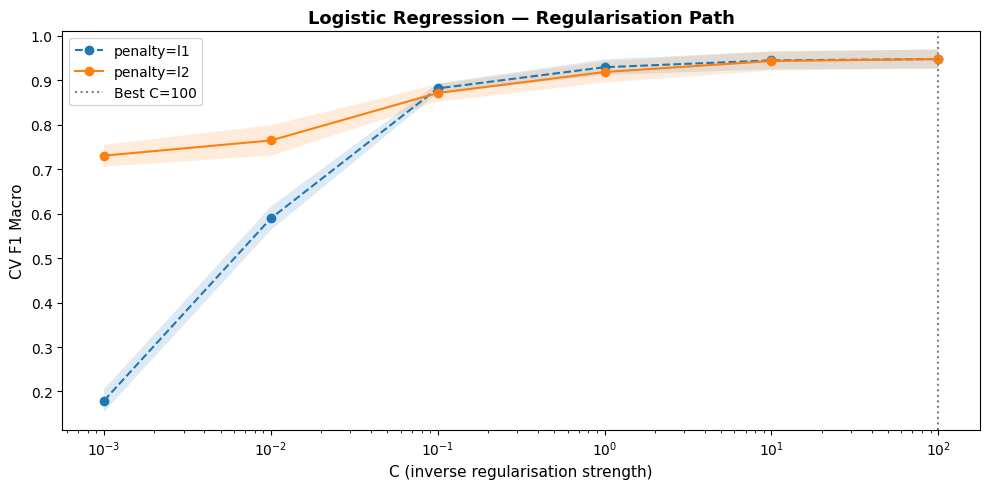

↑ Low C = strong regularisation (high bias). High C = weak regularisation (high variance).
  Shaded band = ±1 std across CV folds.
  L1 often plateaus earlier — sparsity acts as implicit feature selection.


In [5]:
results_df = pd.DataFrame(grid_lr.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
for penalty, ls in [("l1", "--"), ("l2", "-")]:
    sub = results_df[results_df["param_penalty"] == penalty].sort_values("param_C")
    ax.plot(sub["param_C"], sub["mean_test_score"],
            marker="o", ls=ls, label=f"penalty={penalty}")
    ax.fill_between(
        sub["param_C"],
        sub["mean_test_score"] - sub["std_test_score"],
        sub["mean_test_score"] + sub["std_test_score"],
        alpha=0.15,
    )

ax.axvline(grid_lr.best_params_["C"], color="gray", ls=":", lw=1.5,
           label=f"Best C={grid_lr.best_params_['C']}")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularisation strength)", fontsize=11)
ax.set_ylabel("CV F1 Macro", fontsize=11)
ax.set_title("Logistic Regression — Regularisation Path", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("lr_regularisation_path")
plt.show()

print("↑ Low C = strong regularisation (high bias). High C = weak regularisation (high variance).")
print("  Shaded band = ±1 std across CV folds.")
print("  L1 often plateaus earlier — sparsity acts as implicit feature selection.")

### DIAGNOSTIC PLOT 3: Posterior Probability Distributions

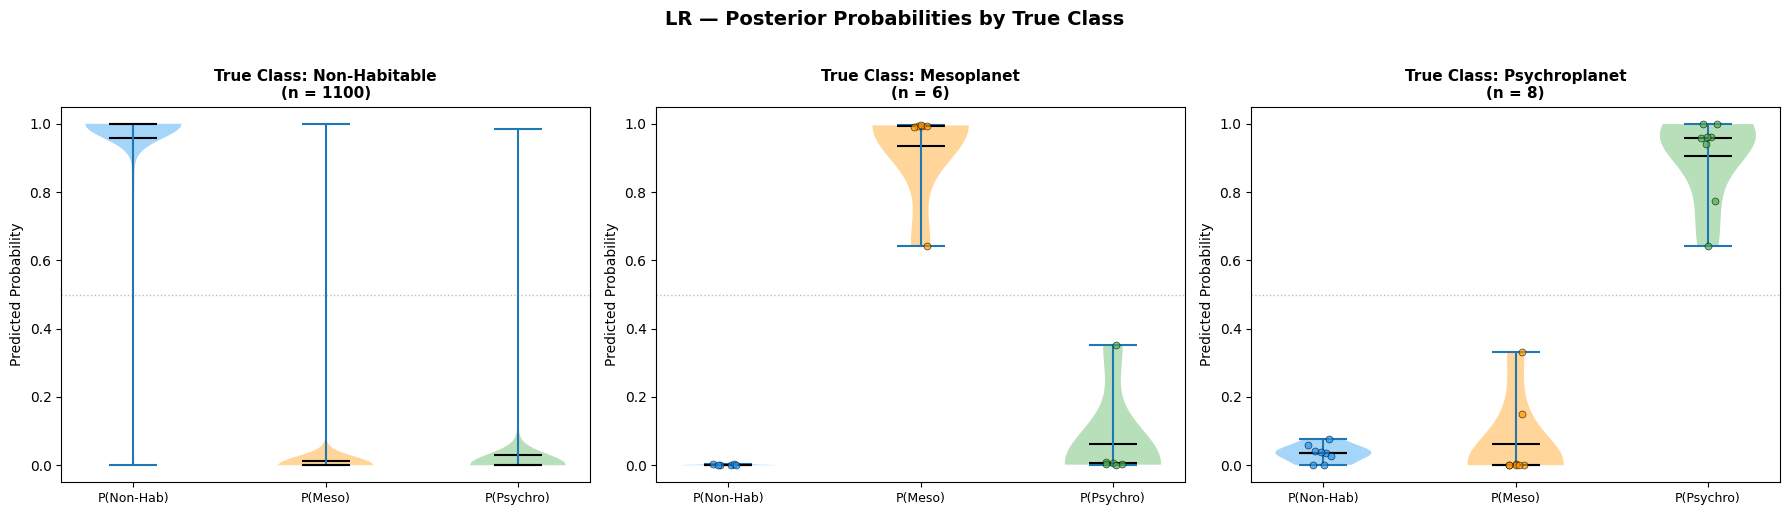

↑ Each panel = predicted probabilities for a specific true class.
  A well-calibrated model concentrates P(true class) near 1.0.
  Logistic regression outputs are Platt-calibrated by construction — smoother than SVM probabilities.


In [6]:
plot_posterior_violins(y_test, y_prob_lr, "LR")

print("↑ Each panel = predicted probabilities for a specific true class.")
print("  A well-calibrated model concentrates P(true class) near 1.0.")
print("  Logistic regression outputs are Platt-calibrated by construction — smoother than SVM probabilities.")

## Metrics
### Classification Report + F1 Scores

LR — Classification Report
               precision    recall  f1-score   support

Non-Habitable     1.0000    0.9664    0.9829      1100
   Mesoplanet     0.3000    1.0000    0.4615         6
Psychroplanet     0.2581    1.0000    0.4103         8

     accuracy                         0.9668      1114
    macro avg     0.5194    0.9888    0.6182      1114
 weighted avg     0.9909    0.9668    0.9760      1114

F1 Macro:    0.6182
F1 Weighted: 0.9760


/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exop


5-Fold CV F1 Macro: 0.9427 ± 0.0103
F1 Macro:    0.6182
F1 Weighted: 0.9760


/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


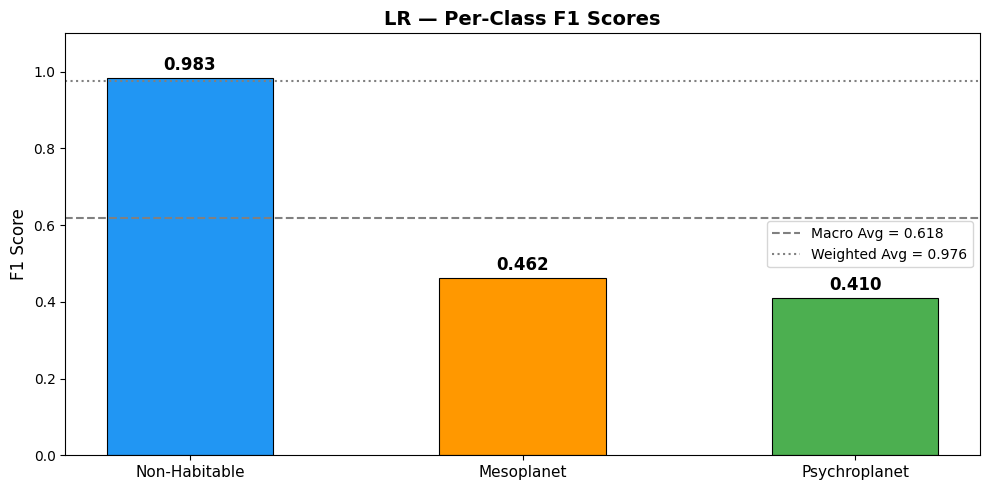

In [7]:
print_classification_report(y_test, y_pred_lr, "LR")

f1_macro_lr, f1_weighted_lr, _ = compute_f1_scores(y_test, y_pred_lr)

cv_scores_lr = run_stratified_cv(lr, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_lr, "LR")

### Confusion Matrices (Counts + Normalized)

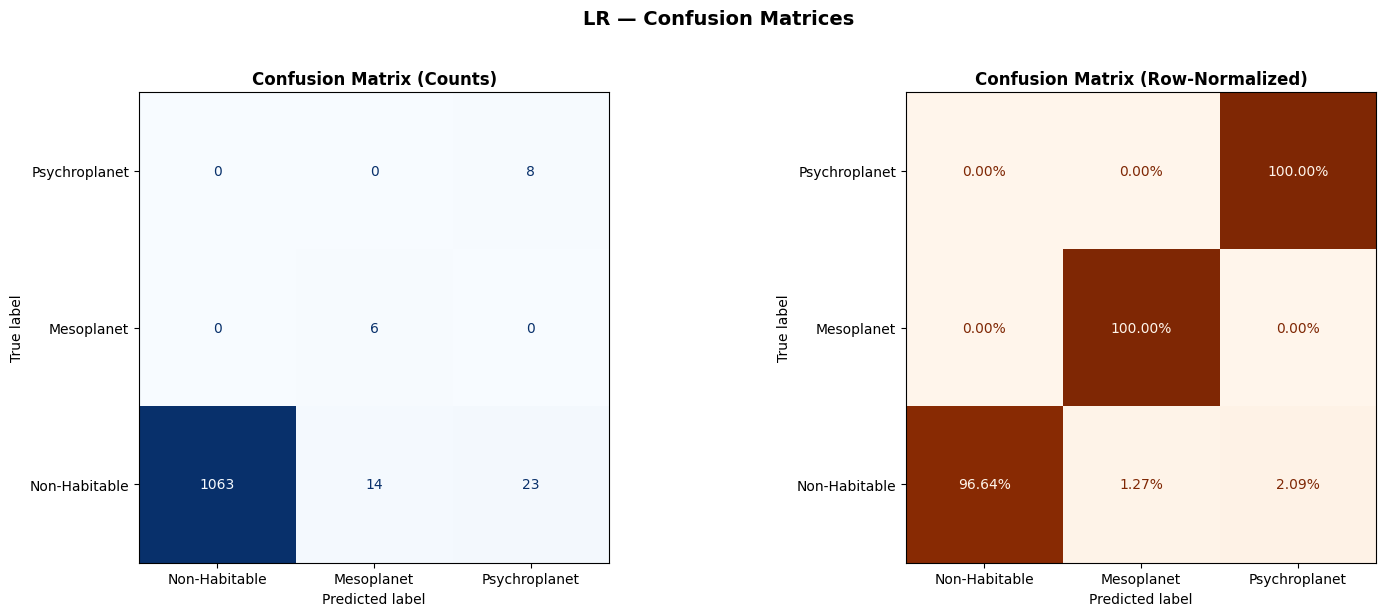

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 14 (1.3% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 23 (2.1% of true Non-Habitable)


In [8]:
plot_confusion_matrices(y_test, y_pred_lr, "LR")
print_error_patterns(y_test, y_pred_lr)

## Interpretation: